<a href="https://colab.research.google.com/github/Sonamgitdata/IIT-MAndi-Deep-learning/blob/main/Assignment1_2_1MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision matplotlib numpy

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.36MB/s]



Training samples: 60000
Testing samples : 10000

MODEL ARCHITECTURE
MNIST_FCNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

STARTING TRAINING
Epoch [ 1/10] Loss: 0.2646 Accuracy: 92.15%
Epoch [ 2/10] Loss: 0.1112 Accuracy: 96.61%
Epoch [ 3/10] Loss: 0.0775 Accuracy: 97.54%
Epoch [ 4/10] Loss: 0.0621 Accuracy: 98.08%
Epoch [ 5/10] Loss: 0.0487 Accuracy: 98.39%
Epoch [ 6/10] Loss: 0.0390 Accuracy: 98.70%
Epoch [ 7/10] Loss: 0.0327 Accuracy: 98.91%
Epoch [ 8/10] Loss: 0.0279 Accuracy: 99.10%
Epoch [ 9/10] Loss: 0.0274 Accuracy: 99.05%
Epoch [10/10] Loss: 0.0214 Accuracy: 99.25%

FINAL TEST RESULT
Test Accuracy: 97.81%


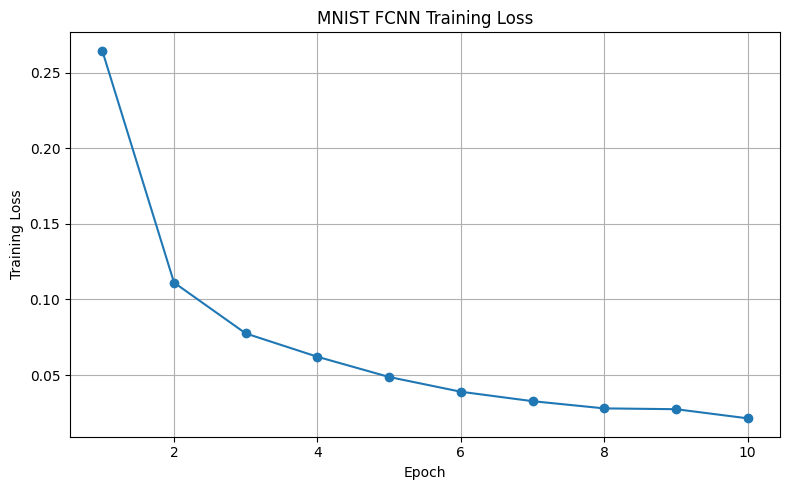

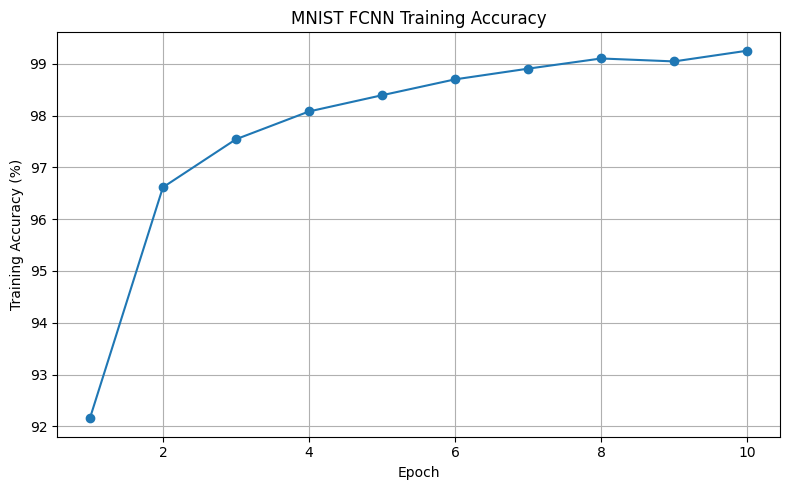


FIRST HIDDEN LAYER WEIGHTS
Weight matrix shape: (128, 784)


/tmp/ipykernel_5898/144487986.py:687: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


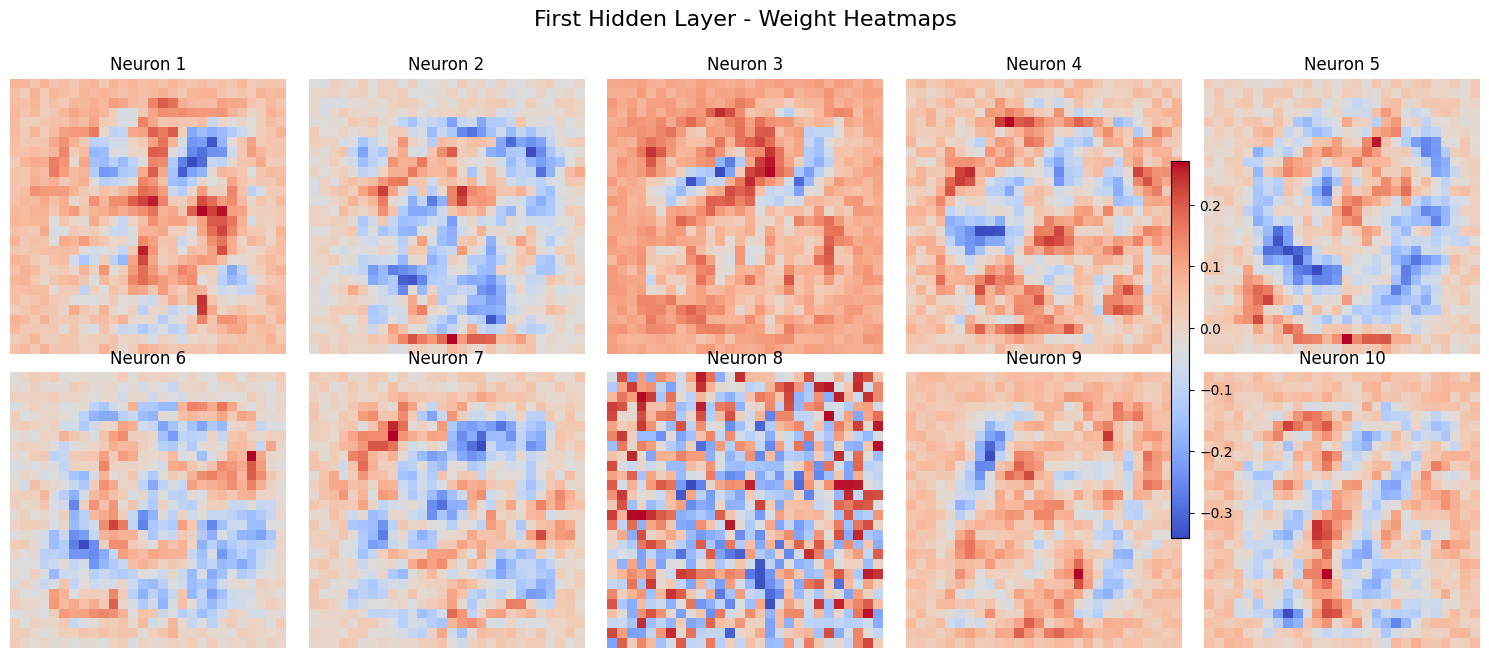


10 SELECTED NEURONS
Neuron 1: Min=-0.4380, Max=0.2801, Mean=0.0010
Neuron 2: Min=-0.3005, Max=0.2838, Mean=-0.0071
Neuron 3: Min=-0.5518, Max=0.2566, Mean=-0.0012
Neuron 4: Min=-0.2800, Max=0.2168, Mean=0.0204
Neuron 5: Min=-0.3145, Max=0.2759, Mean=-0.0069
Neuron 6: Min=-0.3227, Max=0.2869, Mean=-0.0080
Neuron 7: Min=-0.3275, Max=0.2707, Mean=-0.0091
Neuron 8: Min=-0.0445, Max=0.0462, Mean=0.0047
Neuron 9: Min=-0.4624, Max=0.2881, Mean=-0.0099
Neuron 10: Min=-0.3411, Max=0.2719, Mean=0.0055


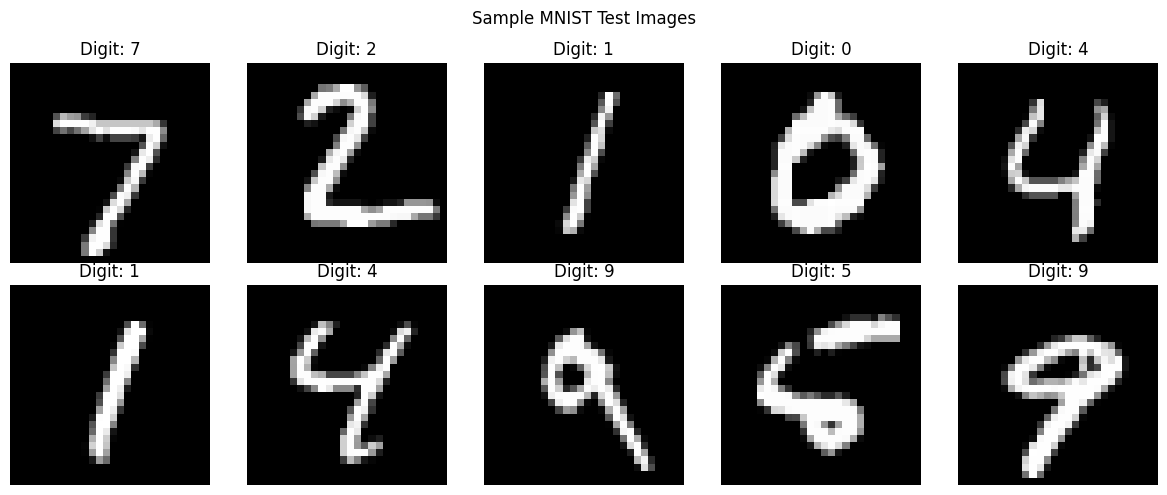


Latent representation shape: (5000, 64)


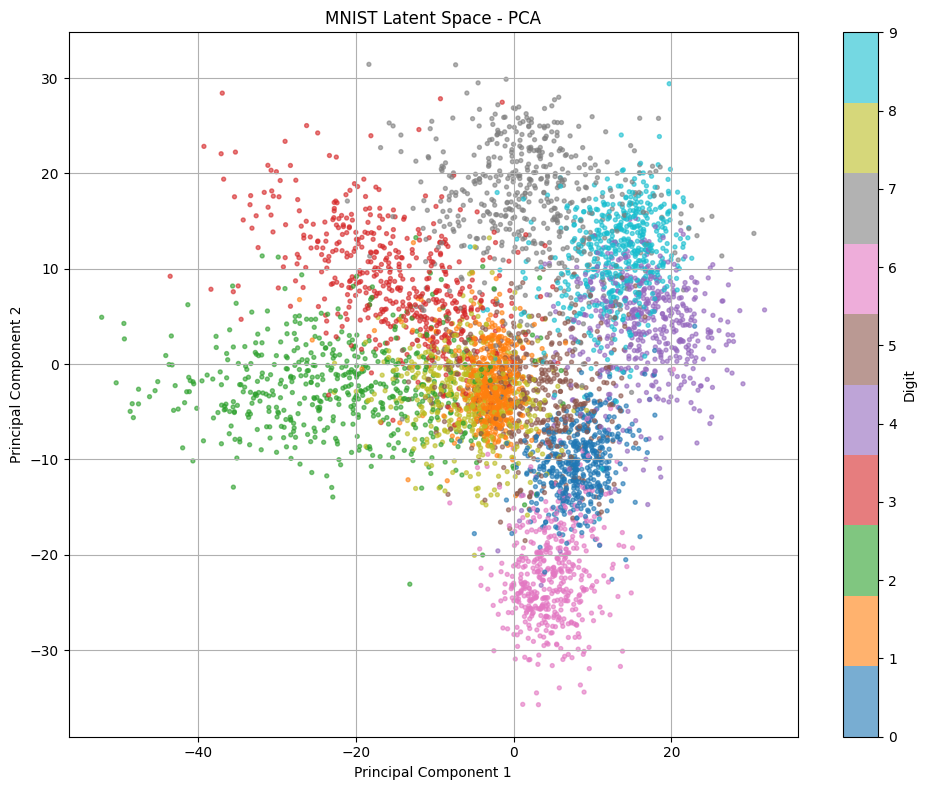


EXPERIMENT COMPLETE
Saved files:
1. training_loss.png
2. training_accuracy.png
3. first_layer_weight_heatmaps.png
4. mnist_samples.png
5. latent_space_pca.png
6. mnist_fcnn.pth


In [2]:
"""
====================================================================
PART 2 - VISION & FEATURE INTERPRETATION
QUESTION 2.1 - WEIGHT VISUALIZATION
====================================================================

Dataset:
    MNIST Handwritten Digits

Goal:
    1. Build an FCNN using PyTorch.
    2. Train the model on MNIST.
    3. Extract weights from the first hidden layer.
    4. Select 10 neurons.
    5. Reshape each neuron's 784 weights into a 28x28 grid.
    6. Visualize these weights as heatmaps.
    7. Analyze the patterns learned by the neurons.
    8. Visualize latent-space representations using PCA.

====================================================================
"""

# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt


# ================================================================
# 2. CONFIGURATION
# ================================================================

# Random seed makes the experiment more reproducible.
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


# Training parameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10


# Network architecture
INPUT_SIZE = 28 * 28       # 784 pixels
HIDDEN_SIZE_1 = 128
HIDDEN_SIZE_2 = 64
OUTPUT_SIZE = 10            # Digits 0-9


# Select CPU or GPU automatically.
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", DEVICE)


# ================================================================
# 3. LOAD MNIST DATASET
# ================================================================

"""
MNIST images are:

    28 x 28 pixels

Each image represents one digit:

    0, 1, 2, ..., 9

To make the data suitable for the neural network:

    1. Convert image to Tensor.
    2. Normalize pixel values.
"""

transform = transforms.Compose([
    transforms.ToTensor(),

    # Normalize grayscale values.
    # Original values are approximately [0, 1].
    # After normalization they are centered around 0.
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])


# Download training data.
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# Download test data.
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ================================================================
# 4. CREATE DATA LOADERS
# ================================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print()
print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))


# ================================================================
# 5. DEFINE THE FCNN MODEL
# ================================================================

class MNIST_FCNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size_1,
        hidden_size_2,
        output_size
    ):

        super().__init__()


        # --------------------------------------------------------
        # First hidden layer
        # --------------------------------------------------------

        self.fc1 = nn.Linear(
            input_size,
            hidden_size_1
        )


        # ReLU activation
        self.relu1 = nn.ReLU()


        # --------------------------------------------------------
        # Second hidden layer
        # --------------------------------------------------------

        self.fc2 = nn.Linear(
            hidden_size_1,
            hidden_size_2
        )


        self.relu2 = nn.ReLU()


        # --------------------------------------------------------
        # Output layer
        # --------------------------------------------------------

        self.fc3 = nn.Linear(
            hidden_size_2,
            output_size
        )


    def forward(self, x):

        # --------------------------------------------------------
        # Convert 28x28 image into 784-dimensional vector
        # --------------------------------------------------------

        x = x.view(
            x.size(0),
            -1
        )


        # --------------------------------------------------------
        # First hidden layer
        # --------------------------------------------------------

        x = self.fc1(x)

        x = self.relu1(x)


        # --------------------------------------------------------
        # Second hidden layer
        # --------------------------------------------------------

        x = self.fc2(x)

        x = self.relu2(x)


        # --------------------------------------------------------
        # Output layer
        # --------------------------------------------------------

        x = self.fc3(x)


        return x


# ================================================================
# 6. CREATE MODEL
# ================================================================

model = MNIST_FCNN(
    INPUT_SIZE,
    HIDDEN_SIZE_1,
    HIDDEN_SIZE_2,
    OUTPUT_SIZE
)


# Move model to CPU/GPU.
model = model.to(DEVICE)


print()
print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)

print(model)


# ================================================================
# 7. LOSS FUNCTION
# ================================================================

"""
CrossEntropyLoss is commonly used for multi-class
classification.

MNIST has 10 classes:

    0, 1, 2, ..., 9
"""

criterion = nn.CrossEntropyLoss()


# ================================================================
# 8. OPTIMIZER
# ================================================================

"""
Adam optimizer updates the model weights during training.

Learning rate:
    0.001
"""

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ================================================================
# 9. STORAGE FOR TRAINING RESULTS
# ================================================================

train_losses = []

train_accuracies = []


# ================================================================
# 10. TRAINING LOOP
# ================================================================

print()
print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)


for epoch in range(EPOCHS):

    # Put model into training mode.
    model.train()


    running_loss = 0.0

    correct = 0

    total = 0


    # ------------------------------------------------------------
    # Process mini-batches
    # ------------------------------------------------------------

    for images, labels in train_loader:

        # Move data to CPU/GPU.
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)


        # --------------------------------------------------------
        # Clear previous gradients
        # --------------------------------------------------------

        optimizer.zero_grad()


        # --------------------------------------------------------
        # Forward pass
        # --------------------------------------------------------

        outputs = model(images)


        # --------------------------------------------------------
        # Calculate loss
        # --------------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # --------------------------------------------------------
        # Backpropagation
        # --------------------------------------------------------

        loss.backward()


        # --------------------------------------------------------
        # Update weights
        # --------------------------------------------------------

        optimizer.step()


        # --------------------------------------------------------
        # Calculate statistics
        # --------------------------------------------------------

        running_loss += (
            loss.item()
            * images.size(0)
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    # ------------------------------------------------------------
    # Epoch results
    # ------------------------------------------------------------

    epoch_loss = (
        running_loss
        / len(train_dataset)
    )


    epoch_accuracy = (
        100.0 * correct / total
    )


    train_losses.append(
        epoch_loss
    )

    train_accuracies.append(
        epoch_accuracy
    )


    print(
        f"Epoch [{epoch + 1:2d}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )


# ================================================================
# 11. TEST THE MODEL
# ================================================================

model.eval()


correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)


        outputs = model(images)


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


test_accuracy = (
    100.0 * correct / total
)


print()
print("=" * 60)
print("FINAL TEST RESULT")
print("=" * 60)

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)


# ================================================================
# 12. PLOT TRAINING LOSS
# ================================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "MNIST FCNN Training Loss"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_loss.png",
    dpi=300
)

plt.show()


# ================================================================
# 13. PLOT TRAINING ACCURACY
# ================================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Training Accuracy (%)")

plt.title(
    "MNIST FCNN Training Accuracy"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_accuracy.png",
    dpi=300
)

plt.show()


# ================================================================
# 14. EXTRACT FIRST HIDDEN LAYER WEIGHTS
# ================================================================

"""
This is the most important part of Question 2.1.

The first layer is:

    self.fc1 = nn.Linear(784, 128)

Therefore:

    128 neurons
    each neuron has 784 weights

Weight matrix shape:

    [128, 784]
"""

first_layer_weights = (
    model.fc1.weight
    .detach()
    .cpu()
    .numpy()
)


print()
print("=" * 60)
print("FIRST HIDDEN LAYER WEIGHTS")
print("=" * 60)

print(
    "Weight matrix shape:",
    first_layer_weights.shape
)


# ================================================================
# 15. SELECT 10 NEURONS
# ================================================================

"""
Select the first 10 neurons.

Each neuron contains:

    784 weights

We will convert:

    784

into:

    28 x 28
"""

num_neurons = 10


selected_weights = (
    first_layer_weights[
        :num_neurons
    ]
)


# ================================================================
# 16. VISUALIZE THE 10 WEIGHT HEATMAPS
# ================================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)


for i, ax in enumerate(
    axes.flat
):

    # ------------------------------------------------------------
    # Get weights belonging to one neuron
    # ------------------------------------------------------------

    neuron_weights = (
        selected_weights[i]
    )


    # ------------------------------------------------------------
    # Reshape 784 weights into 28x28
    # ------------------------------------------------------------

    weight_image = (
        neuron_weights.reshape(
            28,
            28
        )
    )


    # ------------------------------------------------------------
    # Display heatmap
    # ------------------------------------------------------------

    image = ax.imshow(
        weight_image,
        cmap="coolwarm"
    )


    ax.set_title(
        f"Neuron {i + 1}"
    )


    ax.axis("off")


# Add one color bar for interpretation.
fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    shrink=0.7
)


fig.suptitle(
    "First Hidden Layer - Weight Heatmaps",
    fontsize=16
)


plt.tight_layout()


# Save image for the report.
plt.savefig(
    "first_layer_weight_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ================================================================
# 17. PRINT WEIGHT INFORMATION
# ================================================================

print()
print("=" * 60)
print("10 SELECTED NEURONS")
print("=" * 60)


for i in range(
    num_neurons
):

    weights = selected_weights[i]

    print(
        f"Neuron {i + 1}: "
        f"Min={weights.min():.4f}, "
        f"Max={weights.max():.4f}, "
        f"Mean={weights.mean():.4f}"
    )


# ================================================================
# 18. SHOW EXAMPLE MNIST IMAGES
# ================================================================

"""
This section is useful for the report because it lets you
compare actual handwritten digits with the learned weights.
"""

images, labels = next(
    iter(test_loader)
)


plt.figure(
    figsize=(12, 5)
)


for i in range(10):

    plt.subplot(
        2,
        5,
        i + 1
    )


    # MNIST image is 28x28.
    image = images[i].squeeze().numpy()


    plt.imshow(
        image,
        cmap="gray"
    )


    plt.title(
        f"Digit: {labels[i].item()}"
    )


    plt.axis("off")


plt.suptitle(
    "Sample MNIST Test Images"
)


plt.tight_layout()


plt.savefig(
    "mnist_samples.png",
    dpi=300
)


plt.show()


# ================================================================
# 19. LATENT SPACE EXTRACTION
# ================================================================

"""
For latent-space analysis, we take the output of the
second hidden layer.

Instead of using all 60,000 images, we use a subset
to make visualization faster.
"""

model.eval()


latent_vectors = []
latent_labels = []


MAX_LATENT_SAMPLES = 5000


with torch.no_grad():

    collected = 0


    for images, labels in test_loader:

        images = images.to(DEVICE)


        # --------------------------------------------------------
        # Flatten image
        # --------------------------------------------------------

        x = images.view(
            images.size(0),
            -1
        )


        # --------------------------------------------------------
        # First hidden layer
        # --------------------------------------------------------

        x = model.fc1(x)

        x = model.relu1(x)


        # --------------------------------------------------------
        # Second hidden layer
        # --------------------------------------------------------

        x = model.fc2(x)

        x = model.relu2(x)


        # --------------------------------------------------------
        # Store latent representation
        # --------------------------------------------------------

        latent_vectors.append(
            x.cpu().numpy()
        )

        latent_labels.append(
            labels.numpy()
        )


        collected += images.size(0)


        if collected >= MAX_LATENT_SAMPLES:
            break


latent_vectors = np.concatenate(
    latent_vectors,
    axis=0
)[:MAX_LATENT_SAMPLES]


latent_labels = np.concatenate(
    latent_labels,
    axis=0
)[:MAX_LATENT_SAMPLES]


print()
print(
    "Latent representation shape:",
    latent_vectors.shape
)


# ================================================================
# 20. PCA FROM SCRATCH USING NUMPY
# ================================================================

"""
We use PCA to reduce the latent representation to two dimensions.

No sklearn is required.

Steps:

    1. Center the data.
    2. Calculate covariance matrix.
    3. Calculate eigenvalues/eigenvectors.
    4. Select two largest eigenvectors.
    5. Project data onto those two components.
"""


# Center the latent vectors.
latent_centered = (
    latent_vectors
    - latent_vectors.mean(
        axis=0
    )
)


# Covariance matrix.
covariance_matrix = np.cov(
    latent_centered,
    rowvar=False
)


# Eigenvalue decomposition.
eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)


# Sort eigenvalues from largest to smallest.
sorted_indices = np.argsort(
    eigenvalues
)[::-1]


eigenvectors = eigenvectors[
    :,
    sorted_indices
]


# Select two principal components.
principal_components = eigenvectors[
    :,
    :2
]


# Project latent representations.
latent_2d = (
    latent_centered
    @ principal_components
)


# ================================================================
# 21. PLOT LATENT SPACE
# ================================================================

plt.figure(
    figsize=(10, 8)
)


scatter = plt.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)


plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)


plt.title(
    "MNIST Latent Space - PCA"
)


plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)


plt.grid(True)


plt.tight_layout()


plt.savefig(
    "latent_space_pca.png",
    dpi=300
)


plt.show()


# ================================================================
# 22. SAVE TRAINED MODEL
# ================================================================

torch.save(
    model.state_dict(),
    "mnist_fcnn.pth"
)


print()
print("=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)

print(
    "Saved files:"
)

print(
    "1. training_loss.png"
)

print(
    "2. training_accuracy.png"
)

print(
    "3. first_layer_weight_heatmaps.png"
)

print(
    "4. mnist_samples.png"
)

print(
    "5. latent_space_pca.png"
)

print(
    "6. mnist_fcnn.pth"
)